## Imports

In [224]:
%load_ext autoreload
%autoreload 2

import os
import sys
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
from skimage import morphology
import seaborn as sns
import pandas as pd
from aicsimageio import AICSImage

sys.path.append(os.path.relpath("../src"))
from CellAnalyzer import CellAnalyzer
import vetsuisse25_imaging

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [225]:
# import napari

# from napari_convpaint.conv_paint_utils import *
# from napari_convpaint.conv_paint_model import *
# from napari_convpaint.conv_paint_param import Param

In [226]:
virus = "MERS" # "229E" or "MERS"
in_path = "../../imaging_data/21122022_images_jinglecells_SO_AK/" + virus

In [227]:
ca = CellAnalyzer.load(in_path + "/CellAnalyzer/CellAnalyzer.pkl")

>>> GPU activated? NO
>>> GPU activated? NO


## Data loading and inspection

Create an object with the path to the data.

In [228]:
# ca = CellAnalyzer(in_path)

Display the data table.

In [229]:
ca.samples_df

,condition,donor,time,date,sample,replicate,sample_id,mode1,mode2,filename,filepath,projection_types,num_cells,cell_id_min,cell_id_max
0,37mock,BEC5,48h,2021-12-22,00,1,BEC5_1,R3D,D3D,37mock_BEC5_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",343,1,343
1,37mock,BEC5,48h,2021-12-22,01,2,BEC5_2,R3D,D3D,37mock_BEC5_48h_21.12.22.01_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",306,344,649
2,37mock,BEC5,48h,2021-12-22,03,3,BEC5_3,R3D,D3D,37mock_BEC5_48h_21.12.22.03_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",331,650,980
3,37mock,BEC6,48h,2021-12-22,00,1,BEC6_1,R3D,D3D,37mock_BEC6_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",359,981,1339
4,MERS,BEC5,48h,2021-12-22,00,1,BEC5_1,R3D,D3D,MERS_BEC5_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",201,1340,1540
5,MERS,BEC5,48h,2021-12-23,00,2,BEC5_2,R3D,D3D,MERS_BEC5_48h_21.12.23_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",259,1541,1799
6,MERS,BEC6,48h,2021-12-22,01,1,BEC6_1,R3D,D3D,MERS_BEC6_48h_21.12.22.01_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...,"[max, max, max, max]",334,1800,2133


In [230]:
df, imgs = ca.read_data(old_parsing=True)
display(df)

7 images loaded


,condition,donor,time,date,sample,replicate,sample_id,mode1,mode2,filename,filepath
0,37mock,BEC5,48h,2021-12-22,00,1,BEC5_1,R3D,D3D,37mock_BEC5_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
1,37mock,BEC5,48h,2021-12-22,01,2,BEC5_2,R3D,D3D,37mock_BEC5_48h_21.12.22.01_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
2,37mock,BEC5,48h,2021-12-22,03,3,BEC5_3,R3D,D3D,37mock_BEC5_48h_21.12.22.03_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
3,37mock,BEC6,48h,2021-12-22,00,1,BEC6_1,R3D,D3D,37mock_BEC6_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
4,MERS,BEC5,48h,2021-12-22,00,1,BEC5_1,R3D,D3D,MERS_BEC5_48h_21.12.22_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
5,MERS,BEC5,48h,2021-12-23,00,2,BEC5_2,R3D,D3D,MERS_BEC5_48h_21.12.23_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...
6,MERS,BEC6,48h,2021-12-22,01,1,BEC6_1,R3D,D3D,MERS_BEC6_48h_21.12.22.01_R3D_D3D.dv,C:\Users\roman\Documents\Vetsuisse\imaging_dat...


Check dimensions.

In [231]:
imgs[0].shape

(4, 68, 960, 960)

Create projections.

In [232]:
projections = ca.create_projections(types=["max", "max", "max", "max"]) # Projection options: max, min, mean, median

In [233]:
print(ca.projections[0].shape)
print(ca.projections_types)

(4, 960, 960)
['max', 'max', 'max', 'max']


## Segmentation

In [234]:
# masks, flows, styles, imgs_dn, outlines = ca.segment_cells(channels=[3,1]) # Channels for: Cytoplasm, Nucleus

Check to make sure the data was loaded correctly (hiding the irrelevant columns); after segmentation, the table now includes information about the IDs of the cells in each sample.

In [235]:
df = ca.samples_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
df

,condition,donor,replicate,sample_id,num_cells,cell_id_min,cell_id_max
0,37mock,BEC5,1,BEC5_1,343,1,343
1,37mock,BEC5,2,BEC5_2,306,344,649
2,37mock,BEC5,3,BEC5_3,331,650,980
3,37mock,BEC6,1,BEC6_1,359,981,1339
4,MERS,BEC5,1,BEC5_1,201,1340,1540
5,MERS,BEC5,2,BEC5_2,259,1541,1799
6,MERS,BEC6,1,BEC6_1,334,1800,2133


And we now also have a cells table, which contains the information about the sample plus cell-specific information.

In [236]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df.iloc[1300:1305]

,condition,donor,replicate,sample_id,cell_area_px,num_neighbours
cell_id,,,,,,
1301,37mock,BEC6,1,BEC6_1,4684,14
1302,37mock,BEC6,1,BEC6_1,1380,9
1303,37mock,BEC6,1,BEC6_1,1730,12
1304,37mock,BEC6,1,BEC6_1,1977,8
1305,37mock,BEC6,1,BEC6_1,5822,10


Save segmentation results, just for viusalization purposes.

In [237]:
# ca.save_segmentation_imgs(background_channels=[2,4], overwrite=True, norm_img=False)

Save the data, so we can load it later.

In [238]:
# ca.save(overwrite=True)

## Calculate Cell Signals

Mean, or alternatively Median.

In [239]:
signals_mode = "mean" # "mean" or "median"

In [240]:
cells_df, signals_masks = ca.calculate_cell_signals({"cilia": 4, "inf": 2}, dilate=None, mode=signals_mode)

Check the new columns in the data table.

In [241]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df.iloc[1200:1205]

,condition,donor,replicate,sample_id,cell_area_px,num_neighbours,cilia_mean,cilia_mean_log10,inf_mean,inf_mean_log10
cell_id,,,,,,,,,,
1201,37mock,BEC6,1,BEC6_1,1752,12,4685.717466,3.670776,663.558219,2.821879
1202,37mock,BEC6,1,BEC6_1,1312,14,5267.037348,3.721566,680.481707,2.832816
1203,37mock,BEC6,1,BEC6_1,1420,12,4266.040141,3.630025,667.770423,2.824627
1204,37mock,BEC6,1,BEC6_1,2221,11,4862.489869,3.686859,680.087798,2.832565
1205,37mock,BEC6,1,BEC6_1,2076,10,4480.508189,3.651327,664.789017,2.822684


We can also get the masks with the signals for each cell.

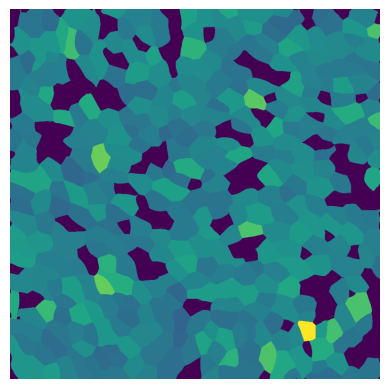

In [242]:
ex_signal_mask = ca.signals_masks["cilia"][3]
plt.imshow(ex_signal_mask)
plt.axis("off")
plt.show()

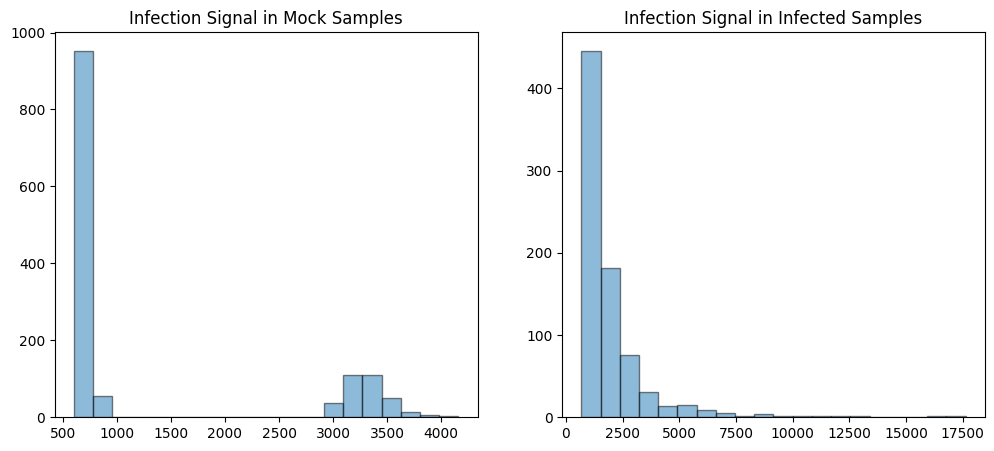

In [243]:
inf_mocks = cells_df[cells_df["condition"].str.contains("mock")]["inf_mean"]
inf_virus = cells_df[cells_df["condition"].str.contains(virus)]["inf_mean"]
fig, ax = plt.subplots(1,2, figsize=(12,5))
for i, data in enumerate([inf_mocks, inf_virus]):
    ax[i].hist(data, bins=20, alpha=0.5, edgecolor='black')
    ax[i].set_title(f"Infection Signal in {'Mock' if i==0 else 'Infected'} Samples")
plt.show()

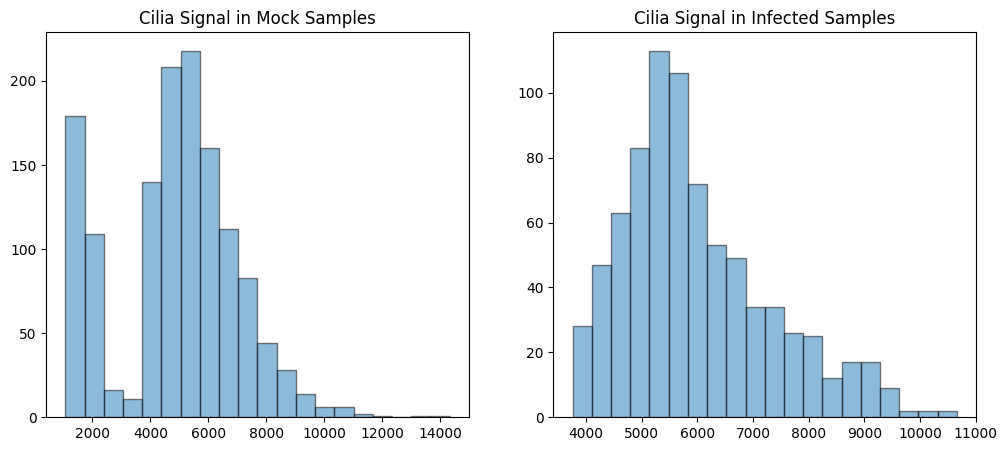

In [244]:
cilia_mocks = cells_df[cells_df["condition"].str.contains("mock")]["cilia_mean"]
cilia_virus = cells_df[cells_df["condition"].str.contains(virus)]["cilia_mean"]
fig, ax = plt.subplots(1,2, figsize=(12,5))
for i, data in enumerate([cilia_mocks, cilia_virus]):
    ax[i].hist(data, bins=20, alpha=0.5, edgecolor='black')
    ax[i].set_title(f"Cilia Signal in {'Mock' if i==0 else 'Infected'} Samples")
plt.show()

Save the data.

In [ ]:
# ca.save(overwrite=True)

## Define inf threshold and bin cells

### Infection

In [246]:
mock_inf_log10 = ca.cells_df[cells_df["condition"].str.contains("mock")]["inf_mean_log10"]
inf_log10_thresh = mock_inf_log10.mean() + 3 * mock_inf_log10.std()
inf_log10_thresh_low = mock_inf_log10.mean() + 1 * mock_inf_log10.std()
threshs = [inf_log10_thresh, inf_log10_thresh_low]
print(f"Inf log10 thresholds: {inf_log10_thresh_low} | {inf_log10_thresh}")

Inf log10 thresholds: 3.3048686427237315 | 3.886746802411588


In [247]:
ca.bin_cell_signal("inf", thresh=threshs)

In [248]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df[100:105]

,condition,donor,replicate,sample_id,cell_area_px,num_neighbours,cilia_mean,cilia_mean_log10,inf_mean,inf_mean_log10,inf,"inf_thresh (manual, log10)"
cell_id,,,,,,,,,,,,
101,37mock,BEC5,1,BEC5_1,4066,12,8412.242499,3.924912,787.143876,2.896054,negative,"[3.3048686427237315, 3.886746802411588]"
102,37mock,BEC5,1,BEC5_1,2865,11,6998.027225,3.844976,738.749389,2.868497,negative,"[3.3048686427237315, 3.886746802411588]"
103,37mock,BEC5,1,BEC5_1,2424,11,8252.469059,3.916584,761.763201,2.881820,negative,"[3.3048686427237315, 3.886746802411588]"
104,37mock,BEC5,1,BEC5_1,3518,12,7182.439170,3.856272,734.362422,2.865910,negative,"[3.3048686427237315, 3.886746802411588]"
105,37mock,BEC5,1,BEC5_1,2063,11,5421.504120,3.734120,670.012118,2.826083,negative,"[3.3048686427237315, 3.886746802411588]"


In [249]:
cells_df["inf"].value_counts() # Total counts of infected vs non-infected cells

inf
negative    1579
partial      537
positive      17
Name: count, dtype: int64

In [250]:
inf_mocks = cells_df[cells_df["condition"].str.contains("mock")]["inf"]
inf_mocks.value_counts()/inf_mocks.count()*100 # Show infection in mocks (should be very low...)

inf
negative    75.28006
partial     24.71994
Name: count, dtype: float64

In [251]:
inf_virus = cells_df[cells_df["condition"].str.contains(virus)]["inf"]
inf_virus.value_counts()/inf_virus.count()*100 # Show infection in infected samples

inf
negative    71.914358
partial     25.944584
positive     2.141058
Name: count, dtype: float64

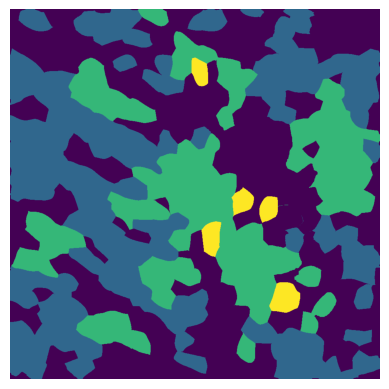

In [252]:
ex_bins_mask = ca.bin_masks["inf"][4]
plt.imshow(ex_bins_mask)
plt.axis("off")
plt.show()

In [253]:
virus_data = cells_df[cells_df["condition"].str.contains(virus)]

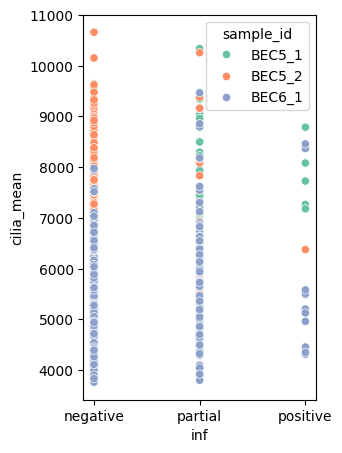

In [254]:
fig, ax = plt.subplots(figsize=(3, 5), dpi=100)
sns.scatterplot(data=virus_data, x='inf', y='cilia_'+signals_mode, palette="Set2", hue="sample_id", ax=ax)
plt.show()

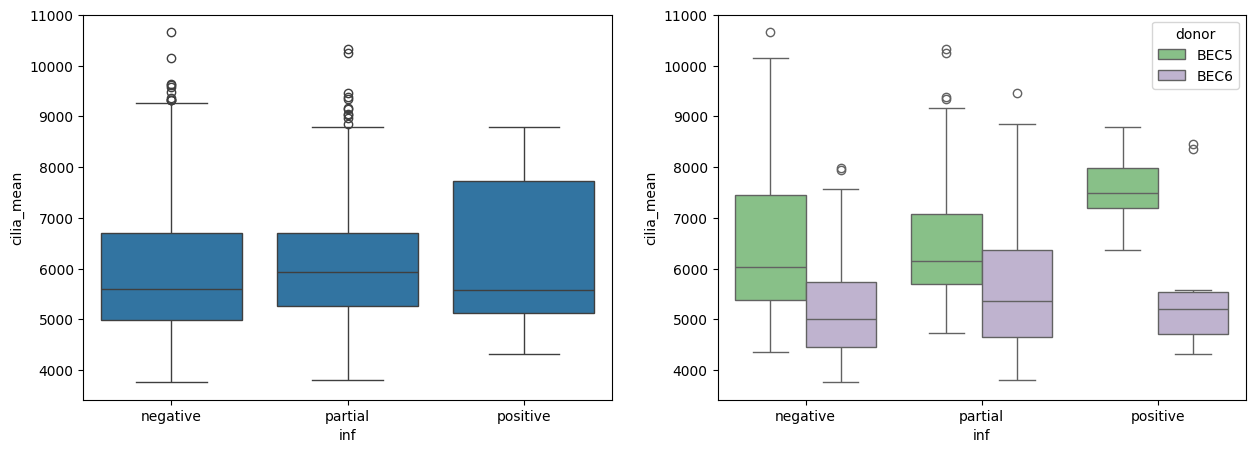

In [255]:
fig, ax = plt.subplots(1,2, figsize=(15, 5), dpi=100)
sns.boxplot(data=virus_data, x='inf', y='cilia_'+signals_mode, ax=ax[0])
sns.boxplot(data=virus_data, x='inf', y='cilia_'+signals_mode, ax=ax[1], palette="Accent", hue="donor")
plt.show()

### Cilia

In [256]:
ca.bin_cell_signal("cilia", thresh=None)

Using Otsu's method to find the threshold for cilia_mean_log10: 3.453369860261881


In [257]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df[100:105]

,condition,donor,replicate,sample_id,cell_area_px,num_neighbours,cilia_mean,cilia_mean_log10,inf_mean,inf_mean_log10,inf,"inf_thresh (manual, log10)",cilia,"cilia_thresh (otsu, log10)"
cell_id,,,,,,,,,,,,,,
101,37mock,BEC5,1,BEC5_1,4066,12,8412.242499,3.924912,787.143876,2.896054,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881]
102,37mock,BEC5,1,BEC5_1,2865,11,6998.027225,3.844976,738.749389,2.868497,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881]
103,37mock,BEC5,1,BEC5_1,2424,11,8252.469059,3.916584,761.763201,2.881820,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881]
104,37mock,BEC5,1,BEC5_1,3518,12,7182.439170,3.856272,734.362422,2.865910,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881]
105,37mock,BEC5,1,BEC5_1,2063,11,5421.504120,3.734120,670.012118,2.826083,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881]


In [258]:
cells_df["cilia"].value_counts()

cilia
positive    1829
negative     304
Name: count, dtype: int64

In [259]:
cilia_mocks = cells_df[cells_df["condition"].str.contains("mock")]["cilia"]
cilia_mocks.value_counts()/cilia_mocks.count()*100 # Show cilia in mocks

cilia
positive    77.29649
negative    22.70351
Name: count, dtype: float64

In [260]:
cilia_virus = cells_df[cells_df["condition"].str.contains(virus)]["cilia"]
cilia_virus.value_counts()/cilia_virus.count()*100 # Show cilia in virus

cilia
positive    100.0
Name: count, dtype: float64

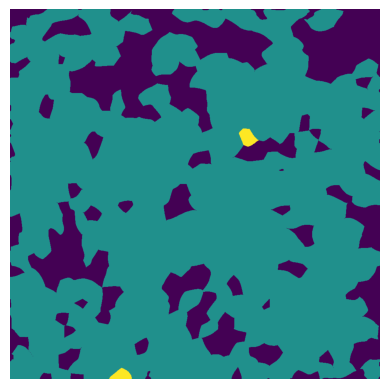

In [261]:
ex_bins_mask = ca.bin_masks["cilia"][1]
plt.imshow(ex_bins_mask)
plt.axis("off")
plt.show()

In [262]:
virus_data = cells_df[cells_df["condition"].str.contains(virus)]

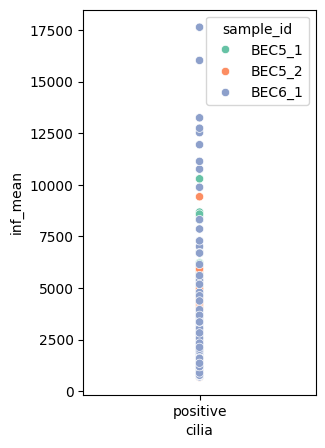

In [263]:
fig, ax = plt.subplots(figsize=(3, 5), dpi=100)
sns.scatterplot(data=virus_data, x='cilia', y='inf_'+signals_mode, palette="Set2", hue="sample_id", ax=ax)
plt.show()

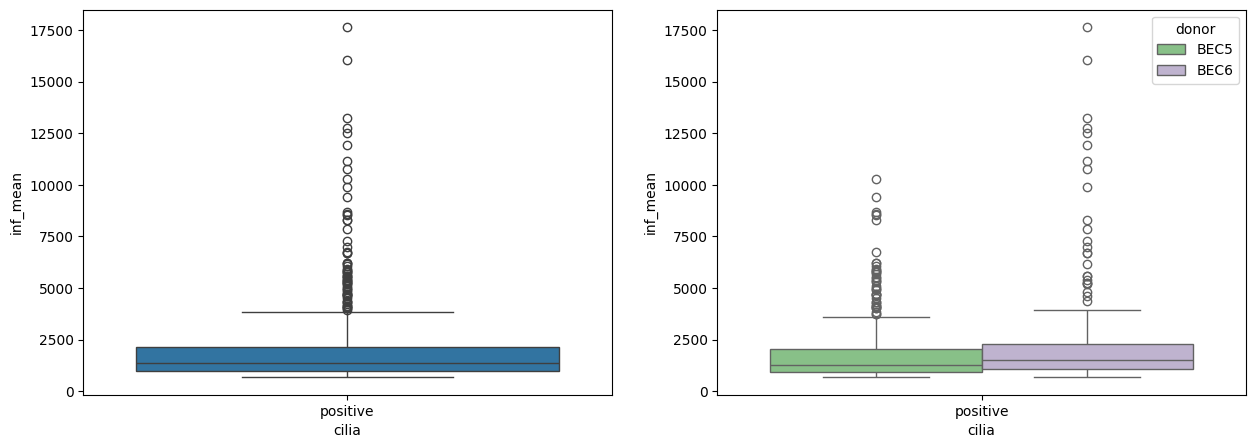

In [264]:
fig, ax = plt.subplots(1,2, figsize=(15, 5), dpi=100)
sns.boxplot(data=virus_data, x='cilia', y='inf_'+signals_mode, ax=ax[0])
sns.boxplot(data=virus_data, x='cilia', y='inf_'+signals_mode, ax=ax[1], palette="Accent", hue="donor")
plt.show()

### Save the data

In [265]:
# ca.save(overwrite=True)

## Extract the populations (bin combinations)

In [266]:
cells_df = ca.create_populations("cilia", "inf")

In [267]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df[100:105]

,condition,donor,replicate,sample_id,cell_area_px,num_neighbours,cilia_mean,cilia_mean_log10,inf_mean,inf_mean_log10,inf,"inf_thresh (manual, log10)",cilia,"cilia_thresh (otsu, log10)",cil_inf_pop
cell_id,,,,,,,,,,,,,,,
101,37mock,BEC5,1,BEC5_1,4066,12,8412.242499,3.924912,787.143876,2.896054,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881],cil_pos_inf_neg
102,37mock,BEC5,1,BEC5_1,2865,11,6998.027225,3.844976,738.749389,2.868497,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881],cil_pos_inf_neg
103,37mock,BEC5,1,BEC5_1,2424,11,8252.469059,3.916584,761.763201,2.881820,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881],cil_pos_inf_neg
104,37mock,BEC5,1,BEC5_1,3518,12,7182.439170,3.856272,734.362422,2.865910,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881],cil_pos_inf_neg
105,37mock,BEC5,1,BEC5_1,2063,11,5421.504120,3.734120,670.012118,2.826083,negative,"[3.3048686427237315, 3.886746802411588]",positive,[3.453369860261881],cil_pos_inf_neg


In [268]:
cells_df["cil_inf_pop"].value_counts()

cil_inf_pop
cil_pos_inf_neg    1275
cil_pos_inf_par     537
cil_neg_inf_neg     304
cil_pos_inf_pos      17
Name: count, dtype: int64

Save population images just for visualization purposes.

In [269]:
ca.save_population_imgs("cilia", "inf", outline_channel="white", overwrite=True)

7 populations saved.
Legend saved with matplotlib.
Folder: ..\..\imaging_data\21122022_images_jinglecells_SO_AK\MERS\populations\cil_inf_pop


Save the data.

In [270]:
# ca.save(overwrite=True)

## Visualize the results

In [271]:
cells_df = ca.cells_df.drop(columns=["time", "date", "sample", "mode1", "mode2", "filename", "filepath", "projection_types"])
cells_df.groupby(["condition", "cilia", "inf"]).size().reset_index(name='count')

,condition,cilia,inf,count
0,37mock,negative,negative,304
1,37mock,positive,negative,704
2,37mock,positive,partial,331
3,MERS,positive,negative,571
4,MERS,positive,partial,206
5,MERS,positive,positive,17


In [272]:
filter = cells_df["condition"].str.contains(virus) & ~cells_df["inf"].str.contains("partial")
virus_data = cells_df[filter]

In [273]:
matrix = virus_data.pivot_table(index="cilia", columns="inf", values="sample_id", aggfunc="count")#.plot(kind="bar", stacked=True, figsize=(10, 5), rot=0)
matrix = matrix.reindex(columns=["negative", "positive"], index=["positive", "negative"]).fillna(0).astype(int)
# matrix = matrix.reindex(columns=["negative", "partial", "positive"], index=["positive", "negative"])
display(matrix)

inf,negative,positive
cilia,,
positive,571,17
negative,0,0


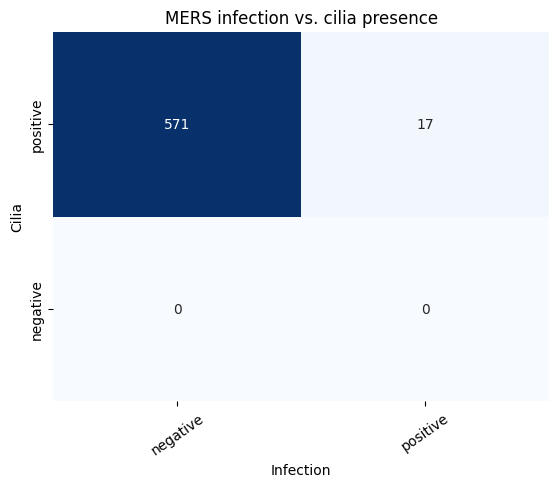

In [274]:
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"{virus} infection vs. cilia presence")
plt.xlabel("Infection")
plt.ylabel("Cilia")
plt.xticks(rotation=35)
plt.show()

inf
negative    1.0
positive    1.0
Name: positive, dtype: float64

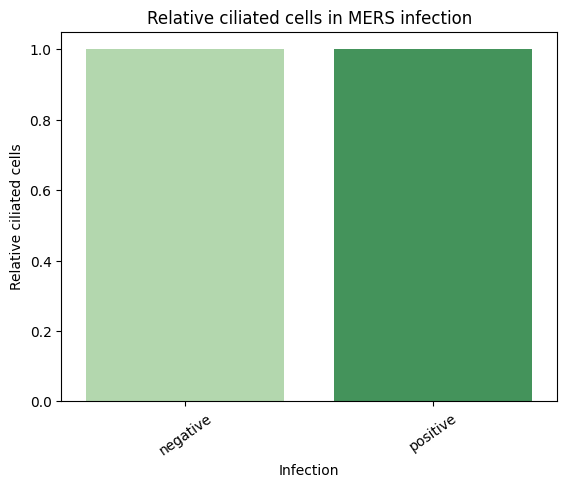

In [275]:
matrix_rel = matrix.div(matrix.sum(axis=0), axis=1)
# Show barplot with only the relative ciliated cells
rel_pos = matrix_rel.loc["positive"]
display(rel_pos)
sns.barplot(x=rel_pos.index, y=rel_pos.values, hue=rel_pos.index, palette="Greens")
plt.title(f"Relative ciliated cells in {virus} infection")
plt.xlabel("Infection")
plt.ylabel("Relative ciliated cells")
plt.xticks(rotation=35)
plt.show()